# Tutorial 7: Making It Rigorous

Every estimate so far has been a single number from a single training run. That
is enough to explore with and not enough to publish. This tutorial covers the
machinery that turns an estimate into a result you can defend.

Three ideas, in order:

1. **One run is one sample.** Re-running with a different seed moves the answer.
   You need to know by how much.
2. **Sweeping a knob** tells you whether your setup is in a sensible regime, and
   `mode='sweep'` runs the grid and aggregates repeats for you.
3. **`mode='rigorous'`** estimates the finite-sample bias directly, by
   re-estimating on deliberately smaller subsets and extrapolating back to
   infinite data.

The third one comes with diagnostics, and the most useful part of this tutorial
is learning to read them. A bias correction you cannot audit is not an
improvement.

## 0. Setup

Correlated Gaussians again, because we need a known answer to grade against.
`SCALE` multiplies sample counts and epochs; committed outputs are at
`SCALE = 1`.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi

SCALE = 1
TRUE_MI, DIM = 2.0, 5
np.random.seed(0)

x, y = nmi.generators.generate_correlated_gaussians(
    n_samples=int(4000 * SCALE), dim=DIM, mi=TRUE_MI)
print(f"x: {tuple(x.shape)}, y: {tuple(y.shape)}   true MI = {TRUE_MI} bits")

x: (4000, 5), y: (4000, 5)   true MI = 2.0 bits


## 1. One run is one sample

The critic is initialised randomly, the split is drawn, and training is
stochastic. Change the seed and you get a different number. Run the same
estimate six times and look at the spread.

In [2]:
seeds = list(range(6))
ests, held = [], []

t0 = time.time()
for s in seeds:
    r = nmi.run(x, y, mode='estimate', split=nmi.Split(mode='random'),
                training=nmi.Training(n_epochs=int(80 * SCALE), patience=25),
                n_workers=1, seed=s, show_progress=False)
    ests.append(r.mi_estimate)
    held.append(r.details['test_mi'])
    print(f"  seed {s}:  mi_estimate = {r.mi_estimate:.3f}   "
          f"test_mi = {r.details['test_mi']:.3f}")

ests, held = np.array(ests), np.array(held)
print(f"\nmi_estimate:  mean {ests.mean():.3f}   sd {ests.std(ddof=1):.3f}   "
      f"range [{ests.min():.3f}, {ests.max():.3f}]")
print(f"test_mi    :  mean {held.mean():.3f}   sd {held.std(ddof=1):.3f}   "
      f"range [{held.min():.3f}, {held.max():.3f}]")
print(f"true MI    :  {TRUE_MI}")
print(f"({time.time() - t0:.0f}s)")

  seed 0:  mi_estimate = 2.130   test_mi = 1.855


  seed 1:  mi_estimate = 2.092   test_mi = 1.737


  seed 2:  mi_estimate = 2.048   test_mi = 1.684


  seed 3:  mi_estimate = 2.067   test_mi = 1.991


neural_mi/analysis/task.py:367: UserWarning: Training completed all 80 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  seed 4:  mi_estimate = 2.137   test_mi = 2.220


  seed 5:  mi_estimate = 2.115   test_mi = 1.811

mi_estimate:  mean 2.098   sd 0.036   range [2.048, 2.137]
test_mi    :  mean 1.883   sd 0.196   range [1.684, 2.220]
true MI    :  2.0
(59s)


**Report a spread, not a point.** The seed-to-seed standard deviation is the
smallest honest error bar on a single estimate, and it costs six training runs
to measure. Quoting three decimal places from one run implies a precision the
method does not have.

Notice also that `mi_estimate` sits above `test_mi` in essentially every row.
That gap is the in-sample optimism from Tutorial 1, and it is systematic rather
than random: averaging more seeds shrinks the scatter and leaves the gap alone.
Section 3 is about removing it.

## 2. Sweeping a knob

`mode='sweep'` takes a `sweep_grid` and runs every combination. Put `run_id` in
the grid and it repeats each combination that many times, which is how you get
error bars without writing a loop.

Here we sweep `embedding_dim`, the width of the representation the critic
compresses each side into. It is the parameter most likely to silently cap your
estimate.

In [3]:
t0 = time.time()
sweep = nmi.run(
    x, y, mode='sweep',
    sweep_grid={'embedding_dim': [2, 8, 32], 'run_id': [0, 1, 2]},
    split=nmi.Split(mode='random'),
    training=nmi.Training(n_epochs=int(120 * SCALE), patience=30),
    n_workers=1, seed=0, show_progress=False,
)

print(sweep.dataframe.to_string(index=False))
print(f"\ntrue MI = {TRUE_MI} bits    ({time.time() - t0:.0f}s)")

 embedding_dim  mi_mean   mi_std
             2 0.762938 0.045535
             8 2.109487 0.017634
            32 2.082591 0.019528

true MI = 2.0 bits    (125s)


**`result.dataframe` arrives aggregated.** One row per grid point, with
`mi_mean` and `mi_std` already computed across the `run_id` repeats. There is no
`mi_estimate` column here, which catches people out; the per-run rows live in
`result.details['raw_results']` if you want them.

The result itself is the lesson: `embedding_dim=2` returns about 0.7 bits
against a true 2.0. The estimator is not wrong, it is answering a different
question, namely how much information survives compression to two dimensions.
At 8 and 32 the bottleneck is gone and the two agree with each other.

**An estimate that is too low may be reporting your architecture rather than
your data.** Sweeping the capacity knob and checking that the answer has stopped
moving is how you rule that out.

In [4]:
raw = sweep.details['raw_results']
print(f"raw_results: {raw.shape[0]} rows, {raw.shape[1]} columns")
print(raw[['embedding_dim', 'run_id', 'train_mi', 'test_mi', 'best_epoch']]
      .sort_values(['embedding_dim', 'run_id']).to_string(index=False))

raw_results: 9 rows, 99 columns
 embedding_dim  run_id  train_mi  test_mi  best_epoch
             2       0  0.795775 0.640897         110
             2       1  0.710956 0.586195          18
             2       2  0.782081 0.758344          80
             8       0  2.094447 1.778107          54
             8       1  2.105120 1.900802          74
             8       2  2.128895 1.997254         116
            32       0  2.080519 2.003634          39
            32       1  2.103073 2.043192          65
            32       2  2.064183 1.998016          43


`raw_results` carries every resolved parameter alongside the outcome, so a
finished sweep records exactly what produced it. `best_epoch` is worth a glance:
if it equals your `n_epochs`, training stopped while still improving and the
estimate is an undertrained lower bound.

**You will have seen that warning fire in this notebook**, which is worth being
straight about. These runs are sized to keep the whole tutorial near ten
minutes, and at that budget a few of them are still improving when the epoch
cap arrives. The warning is doing its job. For a number you intend to report,
raise `n_epochs` until it stops appearing, rather than reading past it.

### Choosing a setting from a sweep

The highest `mi_mean` is rarely the only defensible choice. Settings whose
means sit within one standard deviation of the best are not distinguishable at
this sample size, so among those you may as well take the cheapest.

In [5]:
df = sweep.dataframe
best = df.loc[df['mi_mean'].idxmax()]
tied = df[df['mi_mean'] >= best['mi_mean'] - best['mi_std']]

print(f"best        : embedding_dim = {int(best['embedding_dim'])}  "
      f"mi = {best['mi_mean']:.3f} +/- {best['mi_std']:.3f}")
print(f"within 1 sd : embedding_dim = {sorted(int(v) for v in tied['embedding_dim'])}")
print(f"cheapest tied: embedding_dim = {int(tied['embedding_dim'].min())}")

best        : embedding_dim = 8  mi = 2.109 +/- 0.018
within 1 sd : embedding_dim = [8]
cheapest tied: embedding_dim = 8


## 3. Correcting the bias

The gap between `mi_estimate` and the truth is a finite-sample effect, and it
shrinks as samples grow. `mode='rigorous'` exploits that: it re-estimates on
deliberately reduced subsets, indexed by `gamma`, where `gamma=1` is all the
data and `gamma=k` uses chunks of roughly `1/k` of it. Bias grows with `gamma`,
so fitting MI against `gamma` and reading off the intercept extrapolates to the
infinite-data limit.

The configuration point that bites hardest in practice is subset size. At
`gamma=k` the smallest subset holds about `n_samples / k` points. The library
warns once a chunk's held-out partition can no longer fill one evaluation batch,
which lands near `batch_size / (1 - train_fraction)`. Estimates built from a few
hundred samples are noise, and anchoring an extrapolation on them is worse than
not correcting at all.

**That warning is the one diagnostic the fit cannot replace.** A straight line
drawn through noisy rungs still looks straight, so the linearity check has no way
to tell you the rungs themselves were untrustworthy. It stays a warning rather
than a hard gate for that reason: it is a judgement you have to make.

In [6]:
N_BIG = int(6000 * SCALE)
xb, yb = nmi.generators.generate_correlated_gaussians(
    n_samples=N_BIG, dim=DIM, mi=TRUE_MI)

t0 = time.time()
rig = nmi.run(
    xb, yb, mode='rigorous',
    split=nmi.Split(mode='random'),
    training=nmi.Training(n_epochs=int(60 * SCALE), patience=20),
    model=nmi.Model(embedding_dim=16, hidden_dim=64),
    rigorous=nmi.Rigorous(gamma_range=[1, 2, 3, 4, 5, 6]),
    sweep_grid={'run_id': [0, 1, 2]},
    n_workers=1, seed=0, show_progress=False,
)
d = rig.details
print(f"corrected estimate  : {d['mi_corrected']:.3f} bits")
print(f"mi_error            : {d['mi_error']:.3f}  (confidence interval, half-width)")
print(f"mi_error_pred       : {d['mi_error_pred']:.3f}  (prediction interval, half-width)")
print(f"true MI             : {TRUE_MI}")
print(f"\n({time.time() - t0:.0f}s, {d['n_tasks_created']} training runs)")

2026-08-26 15:00:11 - neural_mi - WARNING - gamma=5: smallest data subset has 1200 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


2026-08-26 15:00:11 - neural_mi - WARNING - gamma=6: smallest data subset has 1000 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


2026-08-26 15:00:11 - neural_mi - WARNING - gamma=5: smallest data subset has 1200 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


2026-08-26 15:00:11 - neural_mi - WARNING - gamma=6: smallest data subset has 1000 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


2026-08-26 15:00:11 - neural_mi - WARNING - gamma=5: smallest data subset has 1200 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


2026-08-26 15:00:11 - neural_mi - WARNING - gamma=6: smallest data subset has 1000 samples, below the ~1281 at which the held-out partition of a chunk can still fill one evaluation batch (batch_size=128, train_fraction=0.9). This is a caution rather than a threshold: MI values from chunks this small are dominated by noise, and a straight line through noisy rungs still looks straight, so the linearity check cannot warn you about it. Prefer a smaller gamma_range or more data. Set 'min_reliable_samples' in base_params to move this line.


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


corrected estimate  : 2.070 bits
mi_error            : 0.022  (confidence interval, half-width)
mi_error_pred       : 0.032  (prediction interval, half-width)
true MI             : 2.0

(253s, 63 training runs)


neural_mi/analysis/rigorous.py:361: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for params, group in valid_df.groupby(group_keys):


**Two error bars, two questions.** `mi_error` is the half-width of the
confidence interval on the fitted intercept, so it answers "how well is the
extrapolated mean pinned down". That is the one to quote in a paper.
`mi_error_pred` is the prediction interval, covering where a single fresh
estimate would land, and it is always the wider of the two. Quote `mi_error`
for the value, and use `mi_error_pred` when you want to know whether a new
run disagreeing with this one would be surprising.

## 4. Reading the diagnostics

`mode='rigorous'` reports how the fit went, and the flags mean specific things.

In [7]:
for k in ['is_reliable', 'linear_region_found', 'enough_gamma_points',
          'curvature_t', 'curvature_coefficient', 'curvature_se',
          'slope', 'r_squared', 'gammas_used', 'saturated_gammas',
          'leverage_warning', 'fit_quality_warning',
          'max_abs_residual', 'loo_intercept_shift']:
    print(f"  {k:22s} = {d[k]}")

per_gamma = rig.dataframe.groupby('gamma')['train_mi'].agg(['mean', 'std'])
print(f"\nMI by subset level:")
print(per_gamma.to_string())

  is_reliable            = True
  linear_region_found    = True
  enough_gamma_points    = True
  curvature_t            = 0.049771289230444285
  curvature_coefficient  = -0.00013191103935248003
  curvature_se           = 0.002650344031510283
  slope                  = -0.00898281895790941
  r_squared              = 0.1256508968630614
  gammas_used            = [1, 2, 3, 4, 5, 6]
  saturated_gammas       = []
  leverage_warning       = False
  fit_quality_warning    = True
  max_abs_residual       = 4.576093307601704
  loo_intercept_shift    = 0.004541562882887871

MI by subset level:
           mean       std
gamma                    
1      2.043846  0.030497
2      2.020617  0.045378
3      2.025412  0.040834
4      2.037113  0.058488
5      2.041345  0.059255
6      2.015608  0.056940


What each one is telling you:

- **`slope`** is the estimated bias per unit `gamma`. A slope near zero means
  there was very little bias to remove, so the correction barely moved the
  number. That is good news about your data, and it makes the next flag
  confusing if you are not expecting it.
- **`r_squared`** measures how much of the variation across gammas the straight
  line explains. When the slope is near zero there is almost no variation to
  explain, so `r_squared` collapses toward zero even though nothing is wrong.
  **Read `r_squared` together with `slope`, never alone.** A low `r_squared` with
  a flat slope means no bias. A low `r_squared` with a steep slope means the
  extrapolation is not trustworthy.
- **`gammas_used`** is the subset of `gamma_range` the fit actually kept. The
  search trims from the top, where the smallest subsets bend the curve, and
  never shrinks below `min_gamma_points`.
- **`curvature_t`** is the statistic the verdict was decided on: the quadratic
  coefficient divided by its own standard error. Below `curvature_t_threshold`
  (default 2.0) the curvature is not distinguishable from noise, and the region
  counts as linear. `curvature_coefficient` and `curvature_se` are its two
  ingredients, reported so the decision can be checked rather than trusted.
- **`linear_region_found`** says whether that criterion was actually
  satisfied on those gammas. False means the search ran all the way down to
  `min_gamma_points` without the relation ever looking straight, so the
  extrapolation is being done on a set that failed the check.
- **`enough_gamma_points`** is the separate question of whether at least
  `min_gamma_points` survived. Splitting these two apart is what lets you tell
  "no linear region anywhere" from "linear, but too few rungs to trust".
- **`is_reliable`** requires both of the above, plus no `leverage_warning` and no
  ceiling-saturated gamma in the fit.
- **`fit_quality_warning`** is informational and deliberately does not affect
  `is_reliable`. It flags large studentized residuals, which the weighted fit
  produces routinely because the repeats at different gammas have genuinely
  different variances.

**`is_reliable` is a statement about the fit, not about the accuracy.** It can
be False on a correction that landed close to the truth, and True on one that
did not. Treat it as a prompt to look at the per-gamma numbers yourself.

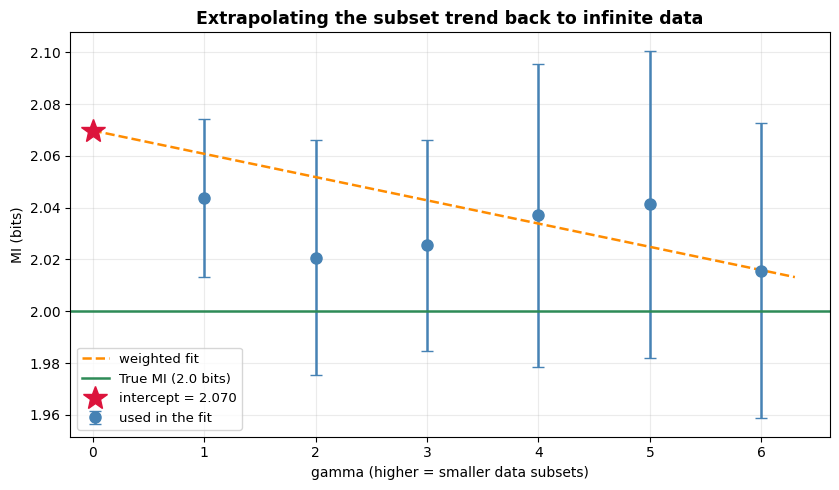

In [8]:
gs = per_gamma.index.to_numpy()
mu, sd = per_gamma['mean'].to_numpy(), per_gamma['std'].fillna(0).to_numpy()
used = set(int(g) for g in d['gammas_used'])
in_fit = np.array([int(g) in used for g in gs])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.errorbar(gs[in_fit], mu[in_fit], yerr=sd[in_fit], fmt='o', ms=8,
            color='steelblue', capsize=4, lw=1.8, label='used in the fit')
if (~in_fit).any():
    ax.errorbar(gs[~in_fit], mu[~in_fit], yerr=sd[~in_fit], fmt='o', ms=8,
                mfc='white', color='steelblue', capsize=4, lw=1.8,
                label='trimmed from the fit')

gg = np.linspace(0, gs.max() * 1.05, 50)
ax.plot(gg, d['mi_corrected'] + d['slope'] * gg, '--', color='darkorange',
        lw=1.8, label='weighted fit')
ax.axhline(TRUE_MI, color='seagreen', lw=1.8, label=f'True MI ({TRUE_MI} bits)')
ax.plot([0], [d['mi_corrected']], '*', ms=18, color='crimson', zorder=5,
        label=f"intercept = {d['mi_corrected']:.3f}")

ax.set_xlabel('gamma (higher = smaller data subsets)')
ax.set_ylabel('MI (bits)')
ax.set_title('Extrapolating the subset trend back to infinite data',
             fontsize=12.5, fontweight='bold')
ax.set_xlim(left=-0.2)
ax.legend(fontsize=9.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The intercept at `gamma = 0` is the corrected estimate. The flatter that line,
the less the correction is doing, and the more of the final number was already
in the uncorrected estimate.

**This run is a good example of the limit of the method.** The slope came out
near zero, so the estimate barely moved across a sixfold range of subset sizes
and the correction had almost nothing to remove. Yet the corrected value still
sits above the true 2.0 by more than `mi_error`.

There is no contradiction. The extrapolation removes the part of the bias that
**depends on sample size**. A bias already present at `gamma=1`, with the full
dataset, is present identically at every gamma, so it rides through into the
intercept untouched. A flat slope says your estimate is stable across `N`,
which is real information about your data. It does not say the estimate is
unbiased, and `mi_error` describes how well the line is pinned down rather than
how far the intercept sits from the truth.

## 5. What rigorous mode costs

The correction is not free. It trains a model per chunk per gamma per repeat, so
the run count grows as the sum of `gamma_range` times the number of repeats.

In [9]:
grange = [1, 2, 3, 4, 5, 6]
n_repeats = 3
print(f"gamma_range = {grange}, run_id repeats = {n_repeats}")
print(f"training runs = sum(gamma_range) * repeats = "
      f"{sum(grange)} * {n_repeats} = {sum(grange) * n_repeats}")
print(f"actually created: {d['n_tasks_created']}")
print(f"\nsmallest subset per gamma (n = {N_BIG}):")
for g in grange:
    flag = "  <-- below the 1000-sample warning threshold" if N_BIG // g < 1000 else ""
    print(f"  gamma {g}:  ~{N_BIG // g} samples{flag}")

gamma_range = [1, 2, 3, 4, 5, 6], run_id repeats = 3
training runs = sum(gamma_range) * repeats = 21 * 3 = 63
actually created: 63

smallest subset per gamma (n = 6000):
  gamma 1:  ~6000 samples
  gamma 2:  ~3000 samples
  gamma 3:  ~2000 samples
  gamma 4:  ~1500 samples
  gamma 5:  ~1200 samples
  gamma 6:  ~1000 samples


Set `n_workers` above 1 for real runs; this notebook pins it to 1 so the
committed output stays deterministic. In a `.py` script rather than a notebook,
`n_workers > 1` needs the usual `if __name__ == '__main__':` guard.

## Key Takeaways

- A single estimate is one draw from a distribution. Six seeds cost little and
  give you the error bar that belongs next to the number.
- `mi_estimate` sits systematically above `test_mi`. Averaging seeds does not
  close that gap, because it is bias rather than scatter.
- `mode='sweep'` returns `result.dataframe` already aggregated as `mi_mean` and
  `mi_std` per grid point. Per-run rows are in `result.details['raw_results']`.
- An estimate that is too low can be your architecture rather than your data.
  Sweep `embedding_dim` until the answer stops moving.
- `mode='rigorous'` fits MI against subset level and reads off the intercept.
  Keep the smallest subsets above about 1000 samples, since no fit diagnostic
  can tell you that the rungs themselves were built from too little data.
- Quote `mi_error` alongside the corrected value. `mi_error_pred` is the wider
  prediction interval and answers a different question. Neither is a claim about
  distance from the truth: a flat slope means no *sample-size-dependent* bias,
  not no bias.
- Among settings within one standard deviation of the best, take the cheapest.
- `is_reliable` describes the fit, not the accuracy. Read `slope` and
  `r_squared` together, and look at the per-gamma numbers before believing a
  correction.

## Common Mistakes

1. **Quoting one run to three decimals.** The seed-to-seed spread here was
   larger than the last two digits. Report a mean and a spread.
2. **Looking for `mi_estimate` in a sweep dataframe.** It is not there. The
   columns are your swept parameters plus `mi_mean` and `mi_std`.
3. **Pushing `gamma` high on a small dataset.** At `gamma=10` with 4000 samples
   the smallest subsets hold 400 points. The library warns; the warning is worth
   obeying, since the extrapolation is then anchored on noise. This is the
   failure the linearity diagnostics cannot see for you, because a steep clean
   trend through bad estimates still looks like a good fit.
4. **Reading `is_reliable=False` as "the number is wrong".** It flags a fit that
   could not be validated. Check `linear_region_found` and `slope`: a flat slope
   means there was nothing to correct in the first place.
6. **Treating `fit_quality_warning` as a failure.** It is informational, fires
   routinely from the weighted fit, and by design does not gate `is_reliable`.

## What's Next

Tutorial 8 adds a third variable. Conditional mutual information asks what X and
Y share once W is accounted for, and interaction information asks whether X and
W tell you overlapping things about Y or complementary ones.